In [1]:
import pandas as pd
import numpy as np
import sys
import os
from sklearn.preprocessing import MinMaxScaler

utils_path = os.path.abspath('../dataset/PopulationStatistics')
if utils_path not in sys.path:
    sys.path.append(utils_path)

from utils import *

In [2]:
file_path = '../dataset/PopulationStatistics/202212_202412_연령별인구현황_연간.csv'
origin_df = pd.read_csv(file_path, encoding = 'cp949')

In [3]:
# origin_df : 원본 데이터셋
# df : 전처리 데이터셋
df = preprocess_df(origin_df)


In [4]:
df.head(5)

,행정구역,연도,성별,연령대,인구수
0,서울특별시 종로구,2022,전체,0~4세,2512
1,서울특별시 종로구,2022,전체,5~9세,3880
2,서울특별시 종로구,2022,전체,10~14세,4703
3,서울특별시 종로구,2022,전체,15~19세,5324
4,서울특별시 종로구,2022,전체,20~24세,9504


In [5]:
# 소멸위험지수 계산 
decline_df = decline_index(df)



In [6]:
# 소멸위험지수 일부 추출
# n : 지역수
# thresh : 수치 - 해당 수치 이하인 경우 다 출력
decline_stat_df1 = get_low_extinction_regions(decline_df, n=10)
decline_stat_df2 = get_low_extinction_regions(decline_df, thresh=0.2)

In [7]:
decline_stat_df1

,행정구역,연도,20~39세_여성,65세_이상_전체,지방소멸지수,소멸위험순위
0,대구광역시 군위군,2024,851,21240,0.040066,1
1,대구광역시 군위군,2023,926,20600,0.044951,1
2,경상북도 봉화군,2024,1128,25076,0.044983,2
3,경상북도 봉화군,2023,1263,24402,0.051758,2
4,경상북도 봉화군,2022,1367,23894,0.057211,2
5,경상북도 의성군,2024,2084,46154,0.045153,3
6,경상북도 의성군,2023,2307,45364,0.050855,3
7,경상북도 의성군,2022,2396,44352,0.054022,3
8,경상남도 합천군,2024,1740,36226,0.048032,4
9,경상남도 합천군,2023,1849,35668,0.051839,4


In [8]:
decline_stat_df2

,행정구역,연도,20~39세_여성,65세_이상_전체,지방소멸지수,소멸위험순위
0,대구광역시 군위군,2024,851,21240,0.040066,1
1,대구광역시 군위군,2023,926,20600,0.044951,1
2,경상북도 봉화군,2024,1128,25076,0.044983,2
3,경상북도 봉화군,2023,1263,24402,0.051758,2
4,경상북도 봉화군,2022,1367,23894,0.057211,2
...,...,...,...,...,...,...
308,충청남도 당진시,2023,14761,70418,0.209620,117
309,충청남도 당진시,2022,15180,67716,0.224172,117
310,경상북도 포항시,2024,43884,220270,0.199228,118
311,경상북도 포항시,2023,45188,207684,0.217581,118


In [9]:
# 시각화
fig = plot_extinction_trend(decline_stat_df1, title='decline_index_trend', save = True)
fig.show()


✅ 그래프가 HTML로 저장되었습니다: ./plot/decline_index_trend.html


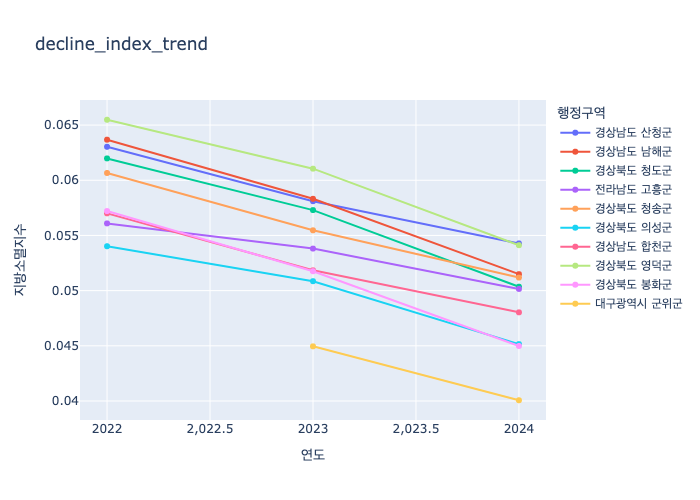

In [10]:

# png 출력용 - 깃에서 보기위함
pio.show(fig, renderer="png")

## for save

In [11]:
pre_decline_df = decline_df[decline_df['연도']==2023].iloc[:,:-1]

pre_decline_df = merge_by_province_city(pre_decline_df)
pre_decline_df['지역소멸지수'] = pre_decline_df['20~39세_여성']/pre_decline_df['65세_이상_전체']


pre_decline_df['소멸위험도'] = 1 / pre_decline_df['지역소멸지수'].replace(0, np.nan)
pre_decline_df['소멸위험도'] = pre_decline_df['소멸위험도'].fillna(pre_decline_df['소멸위험도'].max())
scaler = MinMaxScaler()
pre_decline_df['소멸위험도'] = scaler.fit_transform(pre_decline_df[['소멸위험도']])
pre_decline_df.to_csv('./ref_dataset/01_지역소멸지수.csv')
pre_decline_df




,도시레벨,연도,20~39세_여성,65세_이상_전체,지역소멸지수,소멸위험도
0,강원특별자치도 강릉시,2023,19644,103184,0.190378,0.178304
1,강원특별자치도 고성군,2023,1985,17508,0.113377,0.350803
2,강원특별자치도 동해시,2023,7166,41584,0.172326,0.204911
3,강원특별자치도 삼척시,2023,5089,35986,0.141416,0.266241
4,강원특별자치도 속초시,2023,7515,36880,0.203769,0.161613
...,...,...,...,...,...,...
236,충청북도 제천시,2023,11512,67342,0.170948,0.207172
237,충청북도 증평군,2023,3771,15352,0.245636,0.121168
238,충청북도 진천군,2023,8342,31816,0.262195,0.108735
239,충청북도 청주시,10115,210120,537108,0.391206,0.047918
